In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model_7.set_use_module_grafting(False)
model_7.set_use_scc_status(False)

In [24]:
outputs = model_7(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
model_6.set_use_module_grafting(False)
model_6.set_use_scc_status(False)

In [27]:
outputs = model_6(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6582, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


# 5. Load Save Checkpoints

### 7 Layers

In [28]:
saved_dir_7 = './weights/layer-7-mrpc.pt'
layer_7_point = torch.load(saved_dir_7, map_location='cpu')

In [29]:
layer_7_point.keys()

dict_keys(['model_state_dict', 'layer_track', 'train_stats', 'metrics_after_merge', 'metrics_after_recovery', 'merge_iteration', 'num_layers', 'is_retrained'])

In [30]:
layer_track_7 = layer_7_point['layer_track']
layer_track_7

[[0], [1, 2], [3], [4], [5], [6, 7], [8, 9, 10, 11]]

### 6 Layers

In [31]:
saved_dir_6 = './weights/layer-6-mrpc.pt'
layer_6_point = torch.load(saved_dir_6, map_location='cpu')

In [32]:
layer_6_point.keys()

dict_keys(['model_state_dict', 'layer_track', 'train_stats', 'metrics_after_merge', 'metrics_after_recovery', 'merge_iteration', 'num_layers', 'is_retrained'])

In [33]:
layer_track_6 = layer_6_point['layer_track']
layer_track_6

[[0], [1, 2], [3], [4], [5, 6, 7], [8, 9, 10, 11]]

# 6. Set Models

### 7 Layers

In [34]:
from merge_helper import merge_bert_layers

In [35]:
for i, layer in enumerate(layer_track_7):
    print(i, layer)

0 [0]
1 [1, 2]
2 [3]
3 [4]
4 [5]
5 [6, 7]
6 [8, 9, 10, 11]


In [36]:
for idx, layer in enumerate(layer_track_7):
    if len(layer) > 1:
        for _ in range(len(layer) - 1):
            merged = merge_bert_layers(model_7, idx, idx + 1)
            model_7.bert.encoder.layer[idx] = merged
            del model_7.bert.encoder.layer[idx + 1]

In [37]:
model_7.load_state_dict(layer_7_point['model_state_dict'])

<All keys matched successfully>

In [38]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model_7.to(device)

device

device(type='cuda')

In [39]:
from train_eval_func import eval_loop

In [40]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.875, 'f1': 0.9113043478260869}

In [41]:
eval_loop(model_7, eval_dataloader, task_name, device)[0]

{'accuracy': 0.823768115942029, 'f1': 0.8707482993197279}

### 6 Layers

In [42]:
for idx, layer in enumerate(layer_track_6):
    if len(layer) > 1:
        for _ in range(len(layer) - 1):
            merged = merge_bert_layers(model_6, idx, idx + 1)
            model_6.bert.encoder.layer[idx] = merged
            del model_6.bert.encoder.layer[idx + 1]

In [43]:
model_6.load_state_dict(layer_6_point['model_state_dict'])

<All keys matched successfully>

In [44]:
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model_6.to(device)

device

device(type='cuda')

In [45]:
from train_eval_func import eval_loop

In [46]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.8529411764705882, 'f1': 0.8983050847457628}

In [47]:
eval_loop(model_6, eval_dataloader, task_name, device)[0]

{'accuracy': 0.8127536231884058, 'f1': 0.8670234664470976}

# 7. Visualizations

### 7 Layers

In [50]:
from structure_prune_helper import compute_layer_importance_scores, register_importance_masks, remove_importance_masks

In [52]:
register_importance_masks(model_7, device, register_mha_layer=True, register_mlp_layer=True,
                         register_mha=True, register_mlp=True)

  Layer 0: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 1: Registered (24 heads, 6144 neurons, MHA layer gate, FFN layer gate)
  Layer 2: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 3: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 4: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 5: Registered (24 heads, 6144 neurons, MHA layer gate, FFN layer gate)
  Layer 6: Registered (48 heads, 12288 neurons, MHA layer gate, FFN layer gate)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [53]:
mha_imp, ffn_imp, head_imp, neuron_imp = compute_layer_importance_scores(
            model_7, train_dataloader, device,
            compute_mha=True, compute_ffn=True,
            compute_heads=True, compute_neurons=True)

Computing importance (MHA layer, FFN layer, heads, neurons): 100%|██████████| 115/115 [00:17<00:00,  6.53it/s]


Layer Importance Summary:
          Layer     MHA(layer)     FFN(layer)    Heads(mean)  Neurons(mean)
  ---------------------------------------------------------------------------
  0                     0.7187         0.5374         0.0000         0.0000
  1                     0.6690         0.5563         0.0000         0.0000
  2                     0.6445         0.4346         0.0000         0.0000
  3                     0.5441         0.7580         0.0000         0.0000
  4                     1.0000         0.4584         0.0000         0.0000
  5                     0.3978         1.0000         0.0000         0.0000
  6                     0.4447         0.1876         0.0000         0.0000


In [54]:
import matplotlib.pyplot as plt
import numpy as np

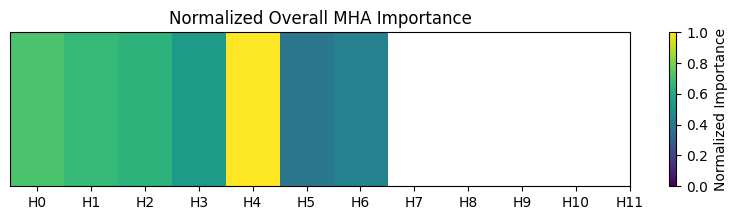

In [55]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    mha_imp.reshape(1, -1),   # or mha_imp[None, :]
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis'
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall MHA Importance")

plt.show()

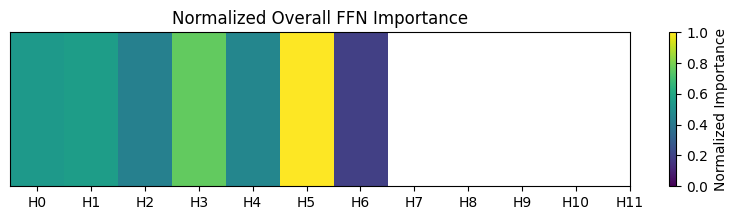

In [56]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    ffn_imp.reshape(1, -1),   # or mha_imp[None, :]
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis'
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [57]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [59]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model_7, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:28<00:00,  4.10it/s]

  Reps Similarity Stats:
    Average: 0.795077
    Highest: 0.918444
    Lowest:  0.675261

  Atts Similarity Stats:
    Average: 0.964557
    Highest: 0.989735
    Lowest:  0.916322
  Sublayer Similarity Stats:
    Average: 0.533417
    Highest: 0.731783
    Lowest:  0.269658


In [62]:
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

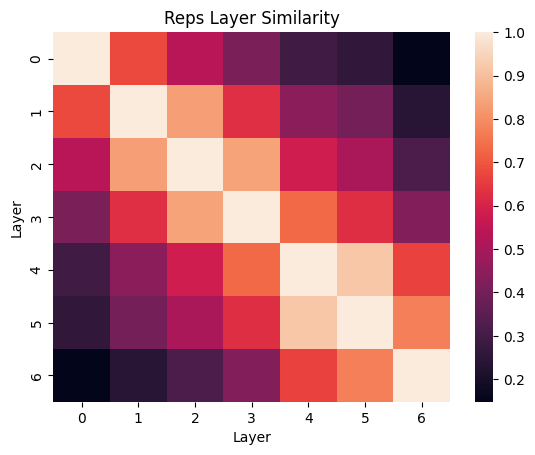

In [63]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

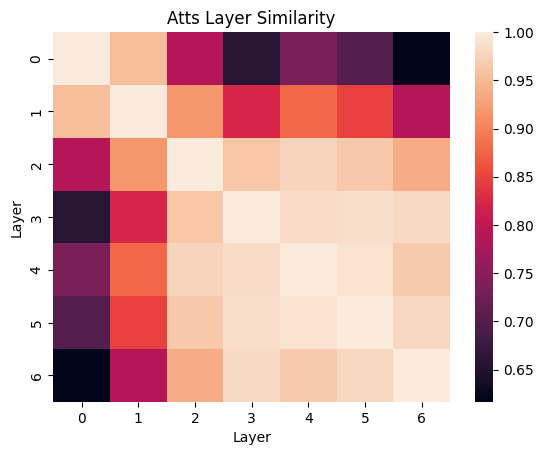

In [64]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

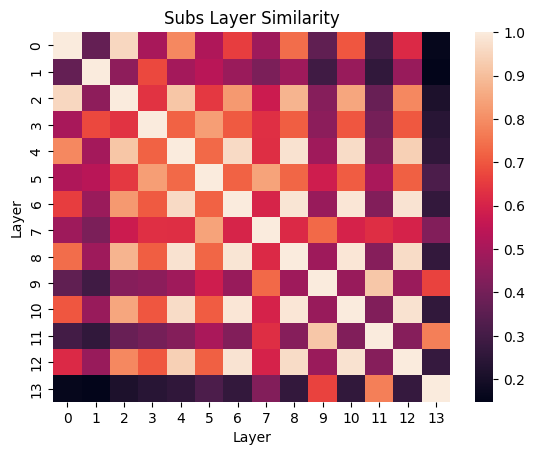

In [65]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

### 6 Layers

In [66]:
register_importance_masks(model_6, device, register_mha_layer=True, register_mlp_layer=True,
                         register_mha=True, register_mlp=True)

  Layer 0: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 1: Registered (24 heads, 6144 neurons, MHA layer gate, FFN layer gate)
  Layer 2: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 3: Registered (12 heads, 3072 neurons, MHA layer gate, FFN layer gate)
  Layer 4: Registered (36 heads, 9216 neurons, MHA layer gate, FFN layer gate)
  Layer 5: Registered (48 heads, 12288 neurons, MHA layer gate, FFN layer gate)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [67]:
mha_imp, ffn_imp, head_imp, neuron_imp = compute_layer_importance_scores(
            model_6, train_dataloader, device,
            compute_mha=True, compute_ffn=True,
            compute_heads=True, compute_neurons=True)

Computing importance (MHA layer, FFN layer, heads, neurons): 100%|██████████| 115/115 [00:17<00:00,  6.68it/s]


Layer Importance Summary:
          Layer     MHA(layer)     FFN(layer)    Heads(mean)  Neurons(mean)
  ---------------------------------------------------------------------------
  0                     0.9307         0.6608         0.0000         0.0000
  1                     1.0000         0.5805         0.0000         0.0000
  2                     0.5849         0.5015         0.0000         0.0000
  3                     0.4819         0.7787         0.0000         0.0000
  4                     0.8686         1.0000         0.0000         0.0000
  5                     0.2834         0.1199         0.0000         0.0000


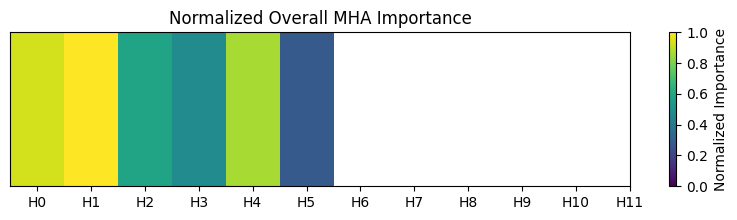

In [69]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    mha_imp.reshape(1, -1),   # or mha_imp[None, :]
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis'
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall MHA Importance")

plt.show()

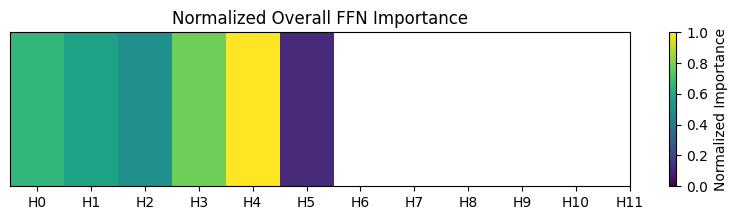

In [70]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    ffn_imp.reshape(1, -1),   # or mha_imp[None, :]
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis'
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [73]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model_6, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:22<00:00,  5.07it/s]

  Reps Similarity Stats:
    Average: 0.734955
    Highest: 0.835413
    Lowest:  0.649042

  Atts Similarity Stats:
    Average: 0.953067
    Highest: 0.978412
    Lowest:  0.925758
  Sublayer Similarity Stats:
    Average: 0.547587
    Highest: 0.730359
    Lowest:  0.221727


Text(50.722222222222214, 0.5, 'Layer')

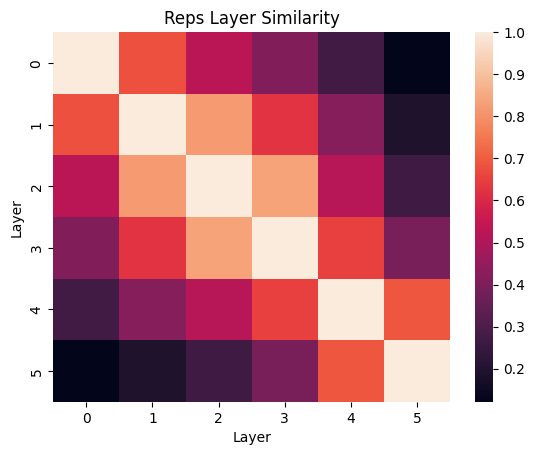

In [74]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

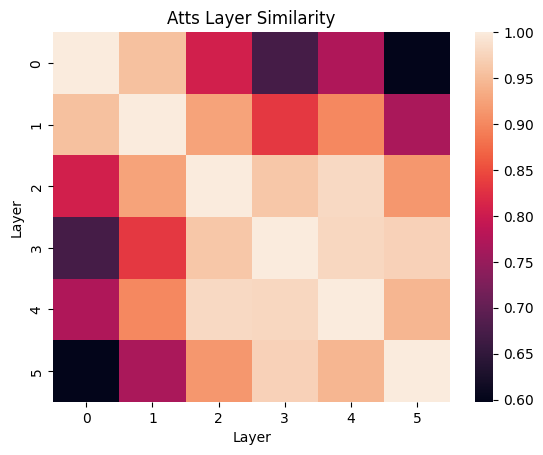

In [75]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

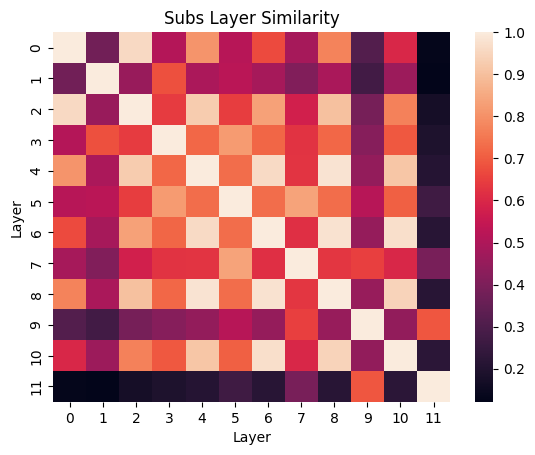

In [76]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

# 8. Hypothesis

### Low Head Sensitivity Merge

In [48]:
from merge_helper import merge_bert_layers

In [49]:
merge_layer = 4

In [50]:
merged = merge_bert_layers(model_7, merge_layer, merge_layer + 1)
model_7.bert.encoder.layer[merge_layer] = merged
# del model_7.bert.encoder.layer[merge_layer + 1]

In [51]:
eval_metric = eval_loop(model_7, val_dataloader, task_name, device)[0]
eval_metric

{'accuracy': 0.8529411764705882, 'f1': 0.8983050847457628}

In [52]:
from torch.optim import AdamW

In [53]:
optimizer = AdamW(model_7.parameters(), lr=1e-5)
teacher_model=None

In [54]:
from train_eval_func import set_lr_scheduler

In [55]:
num_training_steps = 10 * len(train_dataloader)
lr_scheduler = set_lr_scheduler(
    optimizer=optimizer,
    num_training_steps=num_training_steps
)
lr_scheduler = None

In [56]:
from train_eval_func import train

In [57]:
train_stats = train(
        model_7,
        train_dataloader,
        val_dataloader,
        task_name,
        device,
        num_epochs=10,
        lr=1e-5,
        patience=2,
        use_early_stopping=True,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        # save_path=temp_save_path,
        display_epoch_iter=True,
        # teacher_model=teacher_model, alpha=alpha, temperature=temperature
    )

Training:   0%|          | 0/1150 [00:00<?, ?it/s]/home/abhinavl/work/Layer_Graft/layer-grafting-publication/similar_layer_merge/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|█         | 115/1150 [00:21<02:56,  5.85it/s]


<----------------- Epoch 1 ----------------->
Loss: 0.04, Training Metrics:
  accuracy: 0.9891
  f1: 0.9919
Validation Loss: 1.11, Validation Metrics:
  accuracy: 0.8750
  f1: 0.9107
Elapsed Time: 23.0624 sec


Training:  20%|██        | 230/1150 [00:44<02:50,  5.38it/s]


<----------------- Epoch 2 ----------------->
Loss: 0.03, Training Metrics:
  accuracy: 0.9945
  f1: 0.9960
Validation Loss: 1.36, Validation Metrics:
  accuracy: 0.8578
  f1: 0.9010
Elapsed Time: 23.2431 sec


Training:  30%|███       | 345/1150 [01:09<02:42,  4.96it/s]


<----------------- Epoch 3 ----------------->
Loss: 0.02, Training Metrics:
  accuracy: 0.9951
  f1: 0.9964
Validation Loss: 1.43, Validation Metrics:
  accuracy: 0.8480
  f1: 0.8963
Elapsed Time: 23.232 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 69.54 sec
